# Импорт

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("sleep.csv")

print("Первоначальные данные:")
df.head()

Первоначальные данные:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
print(f"Пропущенные значения:\n{df.isnull().sum()}")

Пропущенные значения:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


# Предобработка

1. Разделение Blood Pressure на 2 колонки
2. Кодирование через LabelEncoder Gender, Sleep Disorder
3. Переименование Normal Weight в Normal. Кодирование BMI Category с учетом градации веса
4. Кодирование через One Hot Occupation

In [ ]:
def preprocess_data(df):
    df_processed = df.copy()

    df_processed = df_processed.drop("Person ID", axis=1)

    df_processed["Sleep Disorder"] =  df_processed["Sleep Disorder"].replace(np.nan, "Healthy")


    df_processed[["Systolic_BP", "Diastolic_BP"]] = df_processed["Blood Pressure"].str.split("/", expand=True).astype(float)
    df_processed = df_processed.drop("Blood Pressure", axis=1)

    encoders = {}

    encoders["Gender"] = LabelEncoder()
    df_processed["Gender"] = encoders["Gender"].fit_transform(df_processed["Gender"])
    print(f"Пол закодирован: {dict(zip(encoders["Gender"].classes_, encoders["Gender"].transform(encoders["Gender"].classes_)))}")

    occupation_dummies = pd.get_dummies(df_processed["Occupation"], prefix="Occ", drop_first=True)
    df_processed = pd.concat([df_processed.drop("Occupation", axis=1), occupation_dummies], axis=1)
    print(f"Профессия: добавлено {len(occupation_dummies.columns)} признаков")

    df_processed["BMI Category"] = df_processed["BMI Category"].replace("Normal Weight", "Normal")
    bmi_mapping = {"Normal": 0, "Overweight": 1, "Obese": 2}
    encoders["BMI Category"] = bmi_mapping
    df_processed["BMI_Category"] = df_processed["BMI Category"].map(bmi_mapping)
    df_processed = df_processed.drop("BMI Category", axis=1)
    print(f"ИМТ закодирован: {bmi_mapping}")

    encoders["Sleep Disorder"] = LabelEncoder()
    df_processed["Sleep Disorder"] = encoders["Sleep Disorder"].fit_transform(df_processed["Sleep Disorder"])
    class_mapping = dict(zip(
        encoders["Sleep Disorder"].classes_,
        encoders["Sleep Disorder"].transform(encoders["Sleep Disorder"].classes_)
    ))
    print(f"Целевая переменная закодирована: {class_mapping}")

    return df_processed, encoders


In [ ]:
df_processed, encoders = preprocess_data(df)
print(f"\nРазмерность после обработки: {df_processed.shape}")
print(f"Колонки: {df_processed.columns.tolist()}")

Пол закодирован: {'Female': np.int64(0), 'Male': np.int64(1)}
Профессия: добавлено 10 признаков
ИМТ закодирован: {'Normal': 0, 'Overweight': 1, 'Obese': 2}
Целевая переменная закодирована: {'Healthy': np.int64(0), 'Insomnia': np.int64(1), 'Sleep Apnea': np.int64(2)}

Размерность после обработки: (374, 22)
Колонки: ['Gender', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'Systolic_BP', 'Diastolic_BP', 'Occ_Doctor', 'Occ_Engineer', 'Occ_Lawyer', 'Occ_Manager', 'Occ_Nurse', 'Occ_Sales Representative', 'Occ_Salesperson', 'Occ_Scientist', 'Occ_Software Engineer', 'Occ_Teacher', 'BMI_Category']


In [ ]:
df_processed.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,...,Occ_Engineer,Occ_Lawyer,Occ_Manager,Occ_Nurse,Occ_Sales Representative,Occ_Salesperson,Occ_Scientist,Occ_Software Engineer,Occ_Teacher,BMI_Category
0,1,27,6.1,6,42,6,77,4200,0,126.0,...,False,False,False,False,False,False,False,True,False,1
1,1,28,6.2,6,60,8,75,10000,0,125.0,...,False,False,False,False,False,False,False,False,False,0
2,1,28,6.2,6,60,8,75,10000,0,125.0,...,False,False,False,False,False,False,False,False,False,0
3,1,28,5.9,4,30,8,85,3000,2,140.0,...,False,False,False,False,True,False,False,False,False,2
4,1,28,5.9,4,30,8,85,3000,2,140.0,...,False,False,False,False,True,False,False,False,False,2


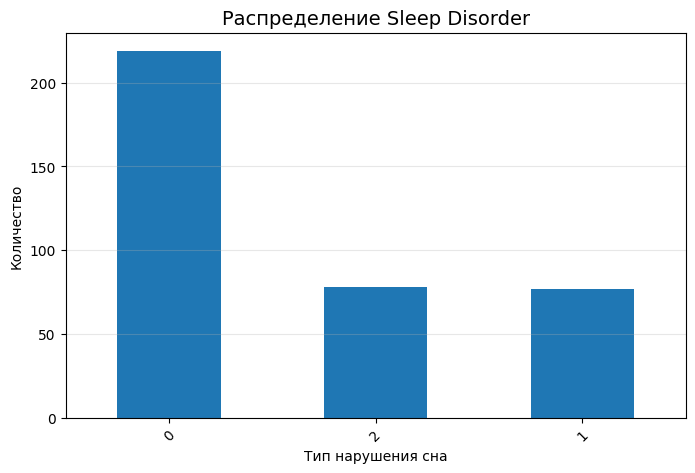

In [ ]:
plt.figure(figsize=(8, 5))
df_processed["Sleep Disorder"].value_counts().plot(kind="bar")
plt.title("Распределение Sleep Disorder", fontsize=14)
plt.xlabel("Тип нарушения сна")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Модели

In [ ]:
num_cols = ["Age", "Stress Level", "Quality of Sleep", "Sleep Duration", "Physical Activity Level",
                  "Heart Rate", "Daily Steps", "Systolic_BP", "Diastolic_BP"]

X = df_processed.drop("Sleep Disorder", axis=1)
y = df_processed["Sleep Disorder"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train
X_test_scaled = X_test
X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])


In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Модель", encoders=None):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    accuracy = accuracy_score(y_test, y_pred)

    print(model_name)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"F1-weighted: {f1_weighted:.4f}")

    if encoders:
        class_names = [str(cls) for cls in encoders["Sleep Disorder"].classes_]
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names if encoders else "auto",
                yticklabels=class_names if encoders else "auto")
    plt.title(f"Матрица ошибок - {model_name}")
    plt.ylabel("Фактическое значение")
    plt.xlabel("Предсказанное значение")
    plt.show()

    return {
        "model": model,
        "name": model_name,
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "y_pred": y_pred
    }

## Модели из 2 лабораторной

Bagging (тюнинг)
Accuracy: 0.9204
F1-macro: 0.8932
F1-weighted: 0.9218

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.94      0.97        66
    Insomnia       0.83      0.83      0.83        23
 Sleep Apnea       0.82      0.96      0.88        24

    accuracy                           0.92       113
   macro avg       0.88      0.91      0.89       113
weighted avg       0.93      0.92      0.92       113



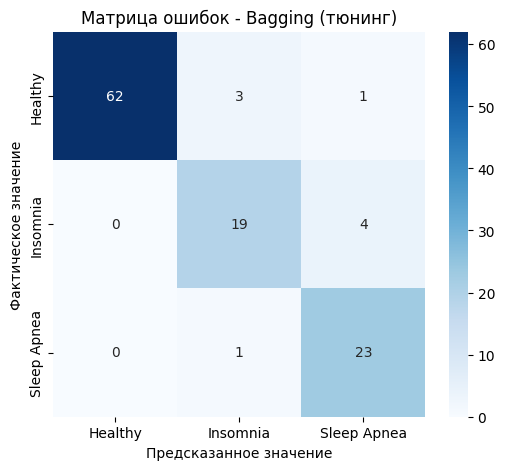

Дерево решений (тюнинг)
Accuracy: 0.9292
F1-macro: 0.9099
F1-weighted: 0.9318

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.94      0.97        66
    Insomnia       0.95      0.87      0.91        23
 Sleep Apnea       0.77      0.96      0.85        24

    accuracy                           0.93       113
   macro avg       0.91      0.92      0.91       113
weighted avg       0.94      0.93      0.93       113



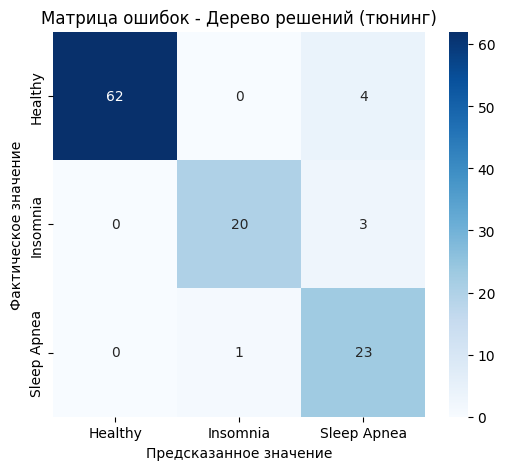

GradientBoosting (тюнинг)
Accuracy: 0.8938
F1-macro: 0.8587
F1-weighted: 0.8973

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.92      0.96        66
    Insomnia       0.73      0.83      0.78        23
 Sleep Apnea       0.81      0.88      0.84        24

    accuracy                           0.89       113
   macro avg       0.85      0.88      0.86       113
weighted avg       0.90      0.89      0.90       113



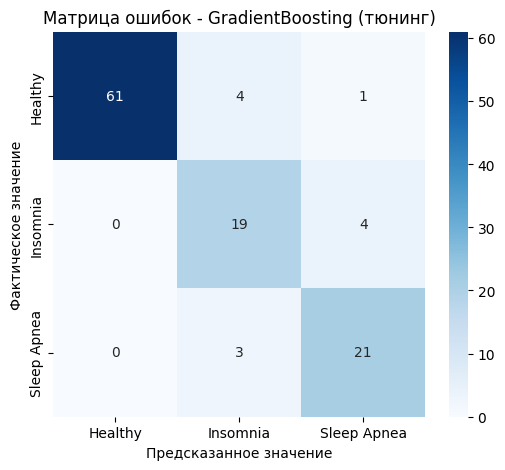

Логистическая регрессия (базовая)
Accuracy: 0.9115
F1-macro: 0.8694
F1-weighted: 0.9128

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.97      0.98        66
    Insomnia       0.82      0.78      0.80        23
 Sleep Apnea       0.78      0.88      0.82        24

    accuracy                           0.91       113
   macro avg       0.87      0.88      0.87       113
weighted avg       0.92      0.91      0.91       113



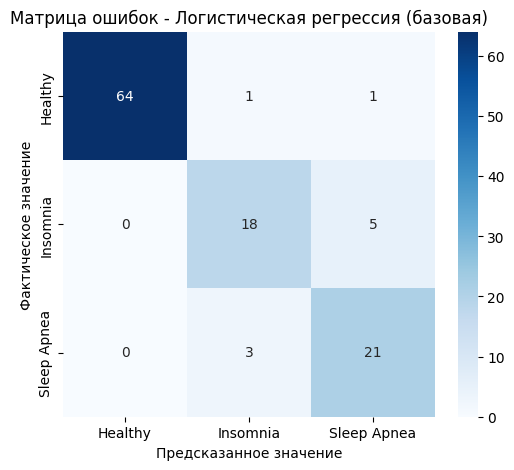

Логистическая регрессия (базовая)
Accuracy: 0.9292
F1-macro: 0.9076
F1-weighted: 0.9307

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.94      0.97        66
    Insomnia       0.87      0.87      0.87        23
 Sleep Apnea       0.82      0.96      0.88        24

    accuracy                           0.93       113
   macro avg       0.90      0.92      0.91       113
weighted avg       0.94      0.93      0.93       113



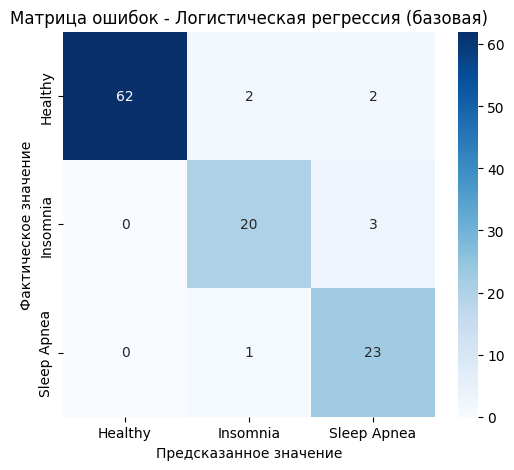

Random Forest (тюнинг)
Accuracy: 0.9204
F1-macro: 0.8932
F1-weighted: 0.9218

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.94      0.97        66
    Insomnia       0.83      0.83      0.83        23
 Sleep Apnea       0.82      0.96      0.88        24

    accuracy                           0.92       113
   macro avg       0.88      0.91      0.89       113
weighted avg       0.93      0.92      0.92       113



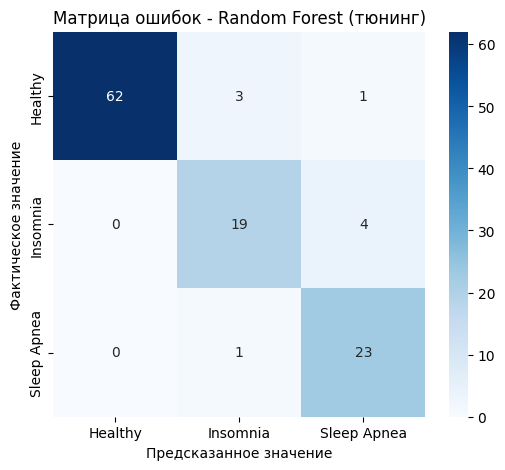

Stacking (тюнинг)
Accuracy: 0.8761
F1-macro: 0.8490
F1-weighted: 0.8789

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.88      0.93        66
    Insomnia       0.78      0.78      0.78        23
 Sleep Apnea       0.74      0.96      0.84        24

    accuracy                           0.88       113
   macro avg       0.84      0.87      0.85       113
weighted avg       0.89      0.88      0.88       113



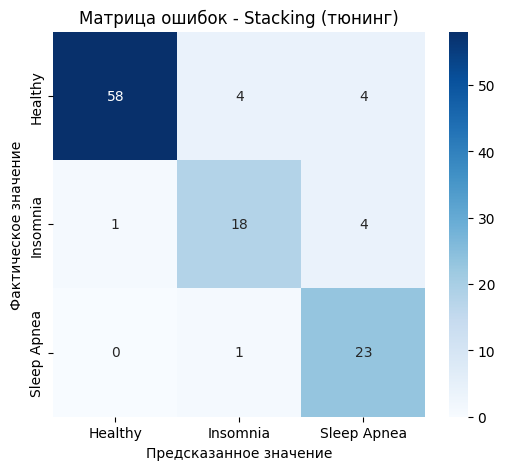

XGBoost (тюнинг)
Accuracy: 0.9204
F1-macro: 0.8891
F1-weighted: 0.9195

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.96      0.98      0.97        66
    Insomnia       0.95      0.78      0.86        23
 Sleep Apnea       0.81      0.88      0.84        24

    accuracy                           0.92       113
   macro avg       0.90      0.88      0.89       113
weighted avg       0.92      0.92      0.92       113



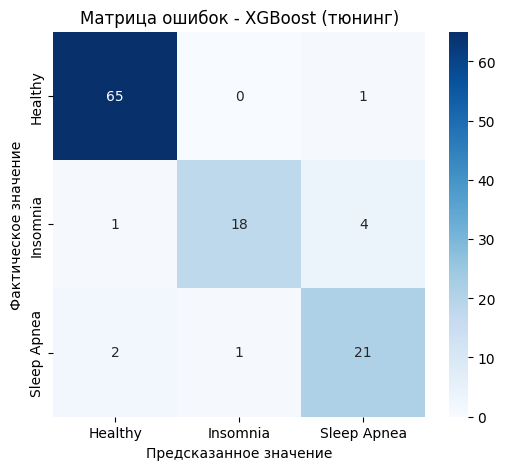

In [ ]:
models = {}
bg_model = joblib.load("Bagging.pkl")
models["Bagging"] = evaluate_model(
    bg_model, X_train, X_test, y_train, y_test,
    "Bagging (тюнинг)", encoders
)

dt_model = joblib.load("DecisionTree.pkl")
models["DecisionTree"] = evaluate_model(
    dt_model, X_train, X_test, y_train, y_test,
    "Дерево решений (тюнинг)", encoders
)

gb_model = joblib.load("GradientBoosting.pkl")
models["GradientBoosting"] = evaluate_model(
    gb_model, X_train, X_test, y_train, y_test,
    "GradientBoosting (тюнинг)", encoders
)

knn_model = joblib.load("KNN.pkl")
models["KNN"] = evaluate_model(
    knn_model, X_train, X_test, y_train, y_test,
    "Логистическая регрессия (базовая)", encoders
)

lr_model = joblib.load("LogReg.pkl")
models["LogReg"] = evaluate_model(
    lr_model, X_train, X_test, y_train, y_test,
    "Логистическая регрессия (базовая)", encoders
)

rf_model = joblib.load("RandomForest.pkl")
models["RandomForest"] = evaluate_model(
    rf_model, X_train, X_test, y_train, y_test,
    "Random Forest (тюнинг)", encoders
)

st_model = joblib.load("Stacking.pkl")
models["Stacking"] = evaluate_model(
    st_model, X_train, X_test, y_train, y_test,
    "Stacking (тюнинг)", encoders
)

xg_model = joblib.load("XGBoost.pkl")
models["XGBoost"] = evaluate_model(
    xg_model, X_train, X_test, y_train, y_test,
    "XGBoost (тюнинг)", encoders
)

In [ ]:
def cross_val(models):
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)
  scoring = "f1_macro"

  for name, model in models.items():
      scores = cross_val_score(model["model"], X_train, y_train, cv=cv, scoring=scoring)
      model.update({
          "scores": scores,
          "mean": scores.mean(),
          "std": scores.std(),
          "min": scores.min(),
          "max": scores.max()
      })

      print(f"\n{name}")
      print(f"Среднее F1-macro: {scores.mean():.4f}")
      print(f"Разброс: от {scores.min():.4f} до {scores.max():.4f}")
      print(f"Все фолды: {[f"{s:.4f}" for s in scores]}")
  return models


Bagging
Среднее F1-macro: 0.8414
Разброс: от 0.8009 до 0.8735
Все фолды: ['0.8735', '0.8645', '0.8056', '0.8009', '0.8625']

DecisionTree
Среднее F1-macro: 0.8490
Разброс: от 0.8146 до 0.9012
Все фолды: ['0.8177', '0.9012', '0.8146', '0.8291', '0.8824']

GradientBoosting
Среднее F1-macro: 0.8465
Разброс: от 0.7745 до 0.9012
Все фолды: ['0.8735', '0.9012', '0.7745', '0.8009', '0.8824']

KNN
Среднее F1-macro: 0.8310
Разброс: от 0.8009 до 0.8735
Все фолды: ['0.8735', '0.8029', '0.8090', '0.8009', '0.8685']

LogReg
Среднее F1-macro: 0.8719
Разброс: от 0.8177 до 0.9093
Все фолды: ['0.8177', '0.9012', '0.8487', '0.9093', '0.8824']

RandomForest
Среднее F1-macro: 0.8533
Разброс: от 0.8058 до 0.8824
Все фолды: ['0.8735', '0.8645', '0.8405', '0.8058', '0.8824']

Stacking
Среднее F1-macro: 0.8629
Разброс: от 0.8230 до 0.9012
Все фолды: ['0.8735', '0.9012', '0.8230', '0.8345', '0.8824']

XGBoost
Среднее F1-macro: 0.8560
Разброс: от 0.8169 до 0.9012
Все фолды: ['0.8735', '0.9012', '0.8169', '0.82

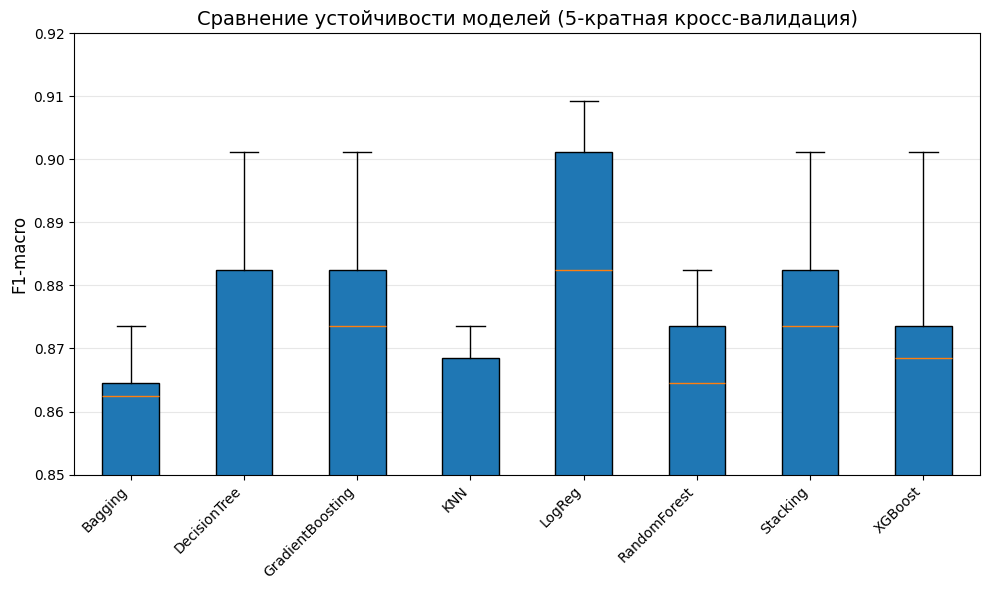

In [ ]:
def boxplot(models):
  fig, ax = plt.subplots(figsize=(10, 6))

  data_to_plot = [models[name]["scores"] for name in models.keys()]
  bp = ax.boxplot(data_to_plot, tick_labels=models.keys(), patch_artist=True)

  ax.set_ylabel("F1-macro", fontsize=12)
  ax.set_title("Сравнение устойчивости моделей (5-кратная кросс-валидация)", fontsize=14)
  ax.grid(axis="y", alpha=0.3)
  ax.set_ylim(0.85, 0.92)
  plt.xticks(rotation=45, ha='right')

  plt.tight_layout()
  plt.show()

models = cross_val(models)
boxplot(models)

### Сравнение CV и тестовых результатов

In [ ]:
comparison = pd.DataFrame({
    "Модель": list(models.keys()),
    "CV среднее": [models[name]["mean"] for name in models.keys()],
    "CV std": [models[name]["std"] for name in models.keys()],
    "Тест F1 macro": [models[name]["f1_macro"] for name in models.keys()],
}).round(4)

print("Сортировка по F1 macro на тесте")
comparison_sorted = comparison.sort_values("Тест F1 macro", ascending=False)
print(comparison_sorted.head(5).to_string(index=False))

print("\nСортировка по стабильности (std)")
comparison_sorted = comparison.sort_values("CV std")
print(comparison_sorted.head(5).to_string(index=False))

Сортировка по F1 macro на тесте
      Модель  CV среднее  CV std  Тест F1 macro
DecisionTree      0.8490  0.0358         0.9099
      LogReg      0.8719  0.0342         0.9076
RandomForest      0.8533  0.0276         0.8932
     Bagging      0.8414  0.0314         0.8932
     XGBoost      0.8560  0.0327         0.8891

Сортировка по стабильности (std)
      Модель  CV среднее  CV std  Тест F1 macro
RandomForest      0.8533  0.0276         0.8932
    Stacking      0.8629  0.0295         0.8490
     Bagging      0.8414  0.0314         0.8932
     XGBoost      0.8560  0.0327         0.8891
         KNN      0.8310  0.0328         0.8694


Вывод

Лучшие 3 модели:

*  Логистическая регрессия
*  Decision Tree
*  Random Forest

## GridSearch

In [ ]:
def grid_search(grid):
  start_time = time.time()
  grid.fit(X_train_scaled, y_train)
  end_time = time.time()

  print(f"\nЛучшие параметры: {grid.best_params_}")
  print(f"Лучший F1-macro (CV): {grid.best_score_:.4f}")
  print(f"Время выполнения: {end_time - start_time:.2f} сек")

Логистическая регрессия

Fitting 5 folds for each of 84 candidates, totalling 420 fits

Лучшие параметры: {'C': 5, 'class_weight': None, 'max_iter': 1000, 'solver': 'lbfgs'}
Лучший F1-macro (CV): 0.8838
Время выполнения: 14.41 сек
Результат модели из прошлой лабораторной:  0.9076

Логистическая регрессия (Grid)
Accuracy: 0.9115
F1-macro: 0.8807
F1-weighted: 0.9140

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.94      0.97        66
    Insomnia       0.77      0.87      0.82        23
 Sleep Apnea       0.84      0.88      0.86        24

    accuracy                           0.91       113
   macro avg       0.87      0.89      0.88       113
weighted avg       0.92      0.91      0.91       113



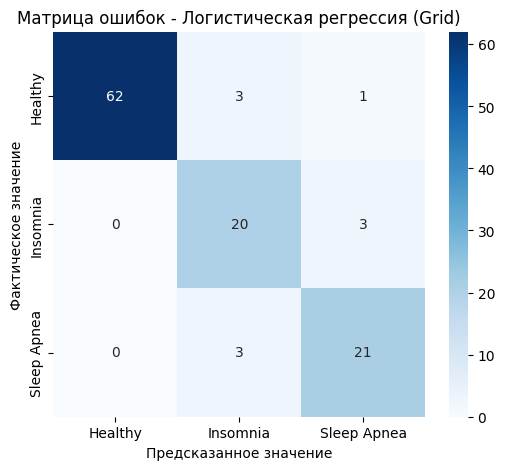

In [ ]:
param_grid_lr = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "solver": ["lbfgs", "newton-cg", "liblinear"],
    "class_weight": [None, "balanced"],
    "max_iter": [1000, 2000]
}

lr = LogisticRegression(random_state=100, penalty="l2")

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_search(grid_lr)
print("Результат модели из прошлой лабораторной: ", round(models["LogReg"]["f1_macro"], 4))
print()
models["LogReg (tuned)"] = evaluate_model(
    grid_lr.best_estimator_, X_train, X_test, y_train, y_test,
    "Логистическая регрессия (Grid)", encoders
)


Decision Tree

Fitting 5 folds for each of 672 candidates, totalling 3360 fits

Лучшие параметры: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший F1-macro (CV): 0.8753
Время выполнения: 27.89 сек
Результат модели из прошлой лабораторной:  0.9099

Decision Tree (Grid)
Accuracy: 0.9292
F1-macro: 0.8966
F1-weighted: 0.9298

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.97      0.98        66
    Insomnia       0.90      0.78      0.84        23
 Sleep Apnea       0.79      0.96      0.87        24

    accuracy                           0.93       113
   macro avg       0.90      0.90      0.90       113
weighted avg       0.94      0.93      0.93       113



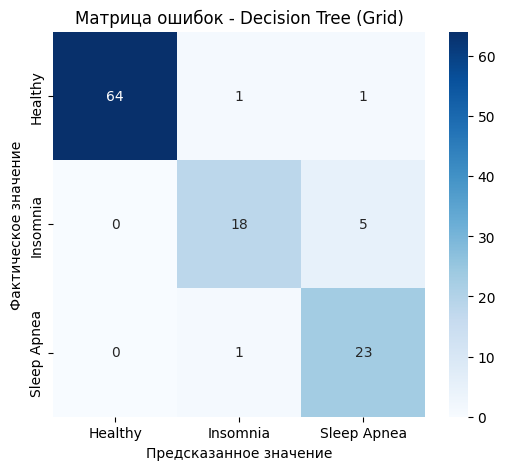

In [ ]:
param_grid_dt = {
    "max_depth": [3, 4, 5, 6, 7, 8, 10, None],
    "min_samples_split": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5, 6],
    "criterion": ["gini", "entropy"]
}

dt = DecisionTreeClassifier(random_state=100)

grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_search(grid_dt)
print("Результат модели из прошлой лабораторной: ", round(models["DecisionTree"]["f1_macro"], 4))
print()
models["DecisionTree (tuned)"] = evaluate_model(
    grid_dt.best_estimator_, X_train, X_test, y_train, y_test,
    "Decision Tree (Grid)", encoders
)

Random Forest

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Лучший F1-macro (CV): 0.8812
Время выполнения: 163.77 сек
Результат модели из прошлой лабораторной:  0.8932

Random Forest (Grid)
Accuracy: 0.9027
F1-macro: 0.8668
F1-weighted: 0.9054

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.94      0.97        66
    Insomnia       0.76      0.83      0.79        23
 Sleep Apnea       0.81      0.88      0.84        24

    accuracy                           0.90       113
   macro avg       0.86      0.88      0.87       113
weighted avg       0.91      0.90      0.91       113



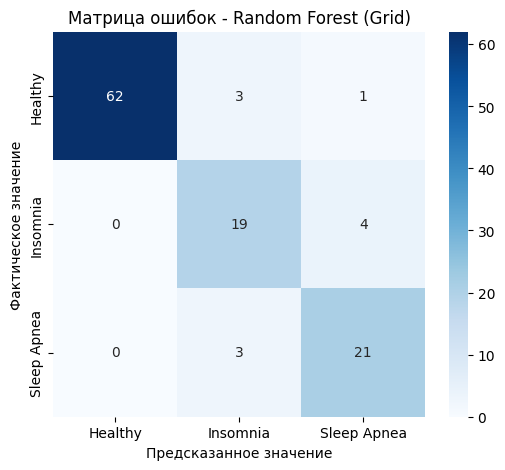

In [ ]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(random_state=100, n_jobs=-1)

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_search(grid_rf)
print("Результат модели из прошлой лабораторной: ", round(models["RandomForest"]["f1_macro"], 4))
print()
models["RandomForest (tuned)"] = evaluate_model(
    grid_rf.best_estimator_, X_train, X_test, y_train, y_test,
    "Random Forest (Grid)", encoders
)


Bagging
Среднее F1-macro: 0.8414
Разброс: от 0.8009 до 0.8735
Все фолды: ['0.8735', '0.8645', '0.8056', '0.8009', '0.8625']

DecisionTree
Среднее F1-macro: 0.8490
Разброс: от 0.8146 до 0.9012
Все фолды: ['0.8177', '0.9012', '0.8146', '0.8291', '0.8824']

GradientBoosting
Среднее F1-macro: 0.8465
Разброс: от 0.7745 до 0.9012
Все фолды: ['0.8735', '0.9012', '0.7745', '0.8009', '0.8824']

KNN
Среднее F1-macro: 0.8310
Разброс: от 0.8009 до 0.8735
Все фолды: ['0.8735', '0.8029', '0.8090', '0.8009', '0.8685']

LogReg
Среднее F1-macro: 0.8719
Разброс: от 0.8177 до 0.9093
Все фолды: ['0.8177', '0.9012', '0.8487', '0.9093', '0.8824']

RandomForest
Среднее F1-macro: 0.8533
Разброс: от 0.8058 до 0.8824
Все фолды: ['0.8735', '0.8645', '0.8405', '0.8058', '0.8824']

Stacking
Среднее F1-macro: 0.8629
Разброс: от 0.8230 до 0.9012
Все фолды: ['0.8735', '0.9012', '0.8230', '0.8345', '0.8824']

XGBoost
Среднее F1-macro: 0.8560
Разброс: от 0.8169 до 0.9012
Все фолды: ['0.8735', '0.9012', '0.8169', '0.82

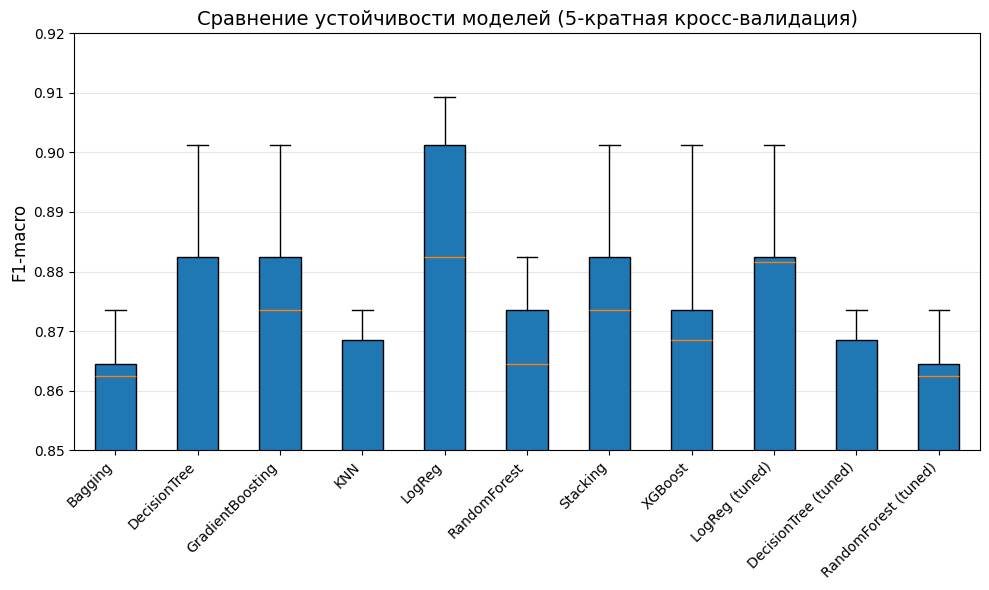

In [ ]:
models = cross_val(models)
boxplot(models)

Random Forest - лучшие параметры: {'class_weight': None, 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

F1-macro: **0.8828**

На CV

Среднее F1-macro: 0.8533

Разброс: от **0.8058** до 0.8824




---


Random Forest (tuned) - лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

F1-macro: **0.8668**


На CV

Среднее F1-macro: 0.8215

Разброс: от **0.6870** до 0.8735



---


**Вывод**: модель tuned показала худшие результаты на cv из-за переобучения


## RFECV

In [ ]:
def cross_val_selected(models):
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)
  scoring = "f1_macro"

  for name, model in models.items():
      scores = cross_val_score(model["model"], X_train_selected, y_train, cv=cv, scoring=scoring)
      model.update({
          "scores": scores,
          "mean": scores.mean(),
          "std": scores.std(),
          "min": scores.min(),
          "max": scores.max()
      })

      print(f"\n{name}")
      print(f"Среднее F1-macro: {scores.mean():.4f}")
      print(f"Разброс: от {scores.min():.4f} до {scores.max():.4f}")
      print(f"Все фолды: {[f"{s:.4f}" for s in scores]}")
  return models

### С Random Forest

In [ ]:
rfecv = RFECV(
    estimator=rf_model,
    step=1,
    cv=5,
    scoring="f1_macro",
    min_features_to_select=2,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
rfecv.fit(X_train_scaled, y_train)
end_time = time.time()

print(f"\nВремя выполнения RFECV: {end_time - start_time:.2f} сек")
print(f"Оптимальное количество признаков: {rfecv.n_features_}")
print(f"Всего признаков: {X_train.shape[1]}")

selected_features = X_train.columns[rfecv.support_].tolist()
print(f"\nОтобранные признаки ({len(selected_features)}):")
for i, feat in enumerate(selected_features):
    print(f"  {i+1}. {feat}")

Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.

Время выполнения RFECV: 24.32 сек
Оптимальное количество признаков: 7
Всего признаков: 21

Отобранные признаки (7):
  1. Age
  2. Sleep Duration
  3. Physical Activity Level
  4. Systolic_BP
  5. Diastolic_BP
  6. Occ_Nurse
  7. BMI_Category


In [ ]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

num_cols_selected = ["Age", "Sleep Duration", "Physical Activity Level", "Systolic_BP", "Diastolic_BP"]
scaler_selected = StandardScaler()
X_train_selected[num_cols_selected] = scaler_selected.fit_transform(X_train_selected[num_cols_selected])
X_test_selected[num_cols_selected] = scaler_selected.transform(X_test_selected[num_cols_selected])

print(f"Размер после отбора: {X_train_selected.shape}")

Размер после отбора: (261, 7)



Bagging
Среднее F1-macro: 0.8496
Разброс: от 0.8009 до 0.8735
Все фолды: ['0.8735', '0.8645', '0.8405', '0.8009', '0.8685']

DecisionTree
Среднее F1-macro: 0.8439
Разброс: от 0.8136 до 0.9032
Все фолды: ['0.8238', '0.9032', '0.8300', '0.8136', '0.8487']

GradientBoosting
Среднее F1-macro: 0.8699
Разброс: от 0.8200 до 0.9012
Все фолды: ['0.8735', '0.9012', '0.8725', '0.8200', '0.8824']

KNN
Среднее F1-macro: 0.8310
Разброс: от 0.8009 до 0.8735
Все фолды: ['0.8735', '0.8029', '0.8090', '0.8009', '0.8685']

LogReg
Среднее F1-macro: 0.8698
Разброс: от 0.8344 до 0.9012
Все фолды: ['0.8344', '0.9012', '0.8487', '0.8963', '0.8685']

RandomForest
Среднее F1-macro: 0.8545
Разброс: от 0.8118 до 0.8824
Все фолды: ['0.8735', '0.8645', '0.8405', '0.8118', '0.8824']

Stacking
Среднее F1-macro: 0.8618
Разброс: от 0.8291 до 0.9012
Все фолды: ['0.8477', '0.9012', '0.8487', '0.8291', '0.8824']

XGBoost
Среднее F1-macro: 0.8576
Разброс: от 0.8200 до 0.9012
Все фолды: ['0.8735', '0.9012', '0.8250', '0.82

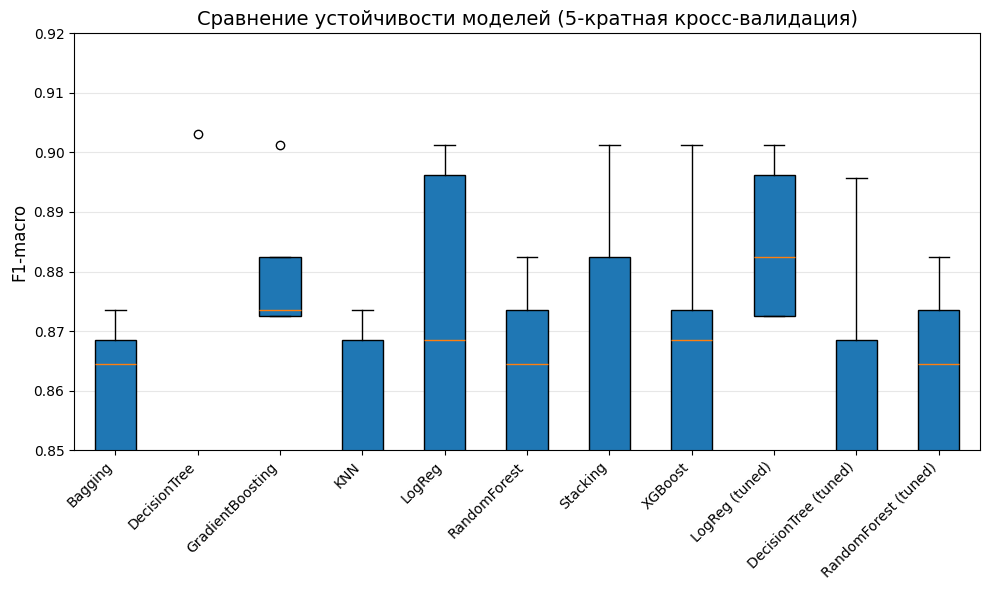

In [ ]:
models_to_test = cross_val_selected(models)
boxplot(models_to_test)

### С логистической регрессией

In [ ]:
rfecv = RFECV(
    estimator=lr_model,
    step=1,
    cv=5,
    scoring="f1_macro",
    min_features_to_select=2,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
rfecv.fit(X_train_scaled, y_train)
end_time = time.time()

print(f"\nВремя выполнения RFECV: {end_time - start_time:.2f} сек")
print(f"Оптимальное количество признаков: {rfecv.n_features_}")
print(f"Всего признаков: {X_train.shape[1]}")

selected_features = X_train.columns[rfecv.support_].tolist()
print(f"\nОтобранные признаки ({len(selected_features)}):")
for i, feat in enumerate(selected_features):
    print(f"  {i+1}. {feat}")

Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.

Время выполнения RFECV: 1.10 сек
Оптимальное количество признаков: 13
Всего признаков: 21

Отобранные признаки (13):
  1. Gender
  2. Sleep Duration
  3. Heart Rate
  4. Daily Steps
  5. Systolic_BP
  6. Diastolic_BP
  7. Occ_Doctor
  8. Occ_Engineer
  9. Occ_Lawyer
  10. Occ_Nurse
  11. Occ_Sales Representative
  12. Occ_Salesperson
  13. Occ_Teacher


In [ ]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

num_cols_selected = ["Sleep Duration", "Systolic_BP", "Diastolic_BP"]
scaler_selected = StandardScaler()
X_train_selected[num_cols_selected] = scaler_selected.fit_transform(X_train_selected[num_cols_selected])
X_test_selected[num_cols_selected] = scaler_selected.transform(X_test_selected[num_cols_selected])

print(f"Размер после отбора: {X_train_selected.shape}")

Размер после отбора: (261, 13)


In [ ]:
print(selected_features)

['Gender', 'Sleep Duration', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP', 'Occ_Doctor', 'Occ_Engineer', 'Occ_Lawyer', 'Occ_Nurse', 'Occ_Sales Representative', 'Occ_Salesperson', 'Occ_Teacher']



Bagging
Среднее F1-macro: 0.8542
Разброс: от 0.8076 до 0.8959
Все фолды: ['0.8735', '0.8959', '0.8076', '0.8118', '0.8824']

DecisionTree
Среднее F1-macro: 0.8622
Разброс: от 0.8070 до 0.9012
Все фолды: ['0.8070', '0.9012', '0.8405', '0.8799', '0.8824']

GradientBoosting
Среднее F1-macro: 0.8361
Разброс: от 0.7444 до 0.9012
Все фолды: ['0.8735', '0.9012', '0.7444', '0.7792', '0.8824']

KNN
Среднее F1-macro: 0.8298
Разброс: от 0.7871 до 0.8824
Все фолды: ['0.8358', '0.8319', '0.7871', '0.8118', '0.8824']

LogReg
Среднее F1-macro: 0.8655
Разброс: от 0.7991 до 0.9107
Все фолды: ['0.7991', '0.9107', '0.8487', '0.8869', '0.8824']

RandomForest
Среднее F1-macro: 0.8520
Разброс: от 0.8009 до 0.8959
Все фолды: ['0.8735', '0.8959', '0.8076', '0.8009', '0.8824']

Stacking
Среднее F1-macro: 0.8823
Разброс: от 0.8230 до 0.9283
Все фолды: ['0.8768', '0.9012', '0.8230', '0.9283', '0.8824']

XGBoost
Среднее F1-macro: 0.8584
Разброс: от 0.8118 до 0.9012
Все фолды: ['0.8735', '0.9012', '0.8230', '0.81

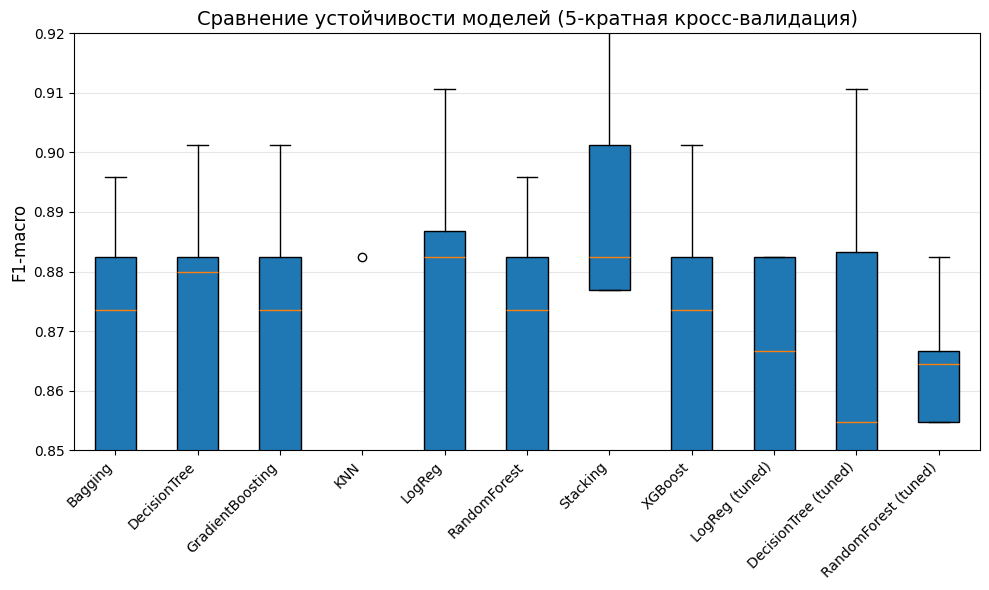

In [ ]:
models_to_test = cross_val_selected(models)
boxplot(models_to_test)

In [ ]:
import joblib
import datetime

for res in models.keys():
  joblib.dump(models[res]["model"], f'Модели/{models[res]["name"]}.pkl')